# Breast Cancer Wisconsin (Diagnostic) Dataset - Project

## Statistical Formulae Used

#### Mean
$$
\mu = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

#### Standard Deviation
$$
\sigma = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2}
$$

#### Normalization (Z-Score)
$$
x_{\text{norm}} = \frac{x - \mu}{\sigma}
$$

## Machine Learning Formulae Used

#### Linear Layer
$$
Z = XW + b
$$

#### ReLU
$$
f(x) = \max(0, x)
$$

#### Sigmoid
$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

#### Loss Function: Binary Cross Entropy
$$
L = -\frac{1}{N} \sum \left[ y \log(p) + (1 - y)\log(1 - p) \right]
$$

#### Backpropagation: Gradient
$$
\frac{\partial L}{\partial Z} = p - y
$$

#### Backpropagation: Weight & Bias Update
$$
W = W - \alpha \cdot dW
$$
$$
b = b - \alpha \cdot db
$$

## Output Metrics
- **True Positive (TP):** Model correctly predicts malignant
- **True Negative (TN):** Model correctly predicts benign
- **False Positive (FP):** Model predicts malignant but actually benign
- **False Negative (FN):** Model predicts benign but actually malignant

#### Accuracy
$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

#### Recall
$$
\text{Recall} = \frac{TP}{TP + FN}
$$

#### False Negative Rate
$$
\text{FNR} = \frac{FN}{TP + FN}
$$

## Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("data.csv")

# Preprocessing
df.drop(axis=0, columns=['id', 'Unnamed: 32'], inplace=True)
df['diagnosis'] = (df['diagnosis'] == 'M').astype(int)
df['diagnosis_label'] = df['diagnosis'].map({0: 'Benign', 1: 'Malignant'})

### Correlation Heatmap

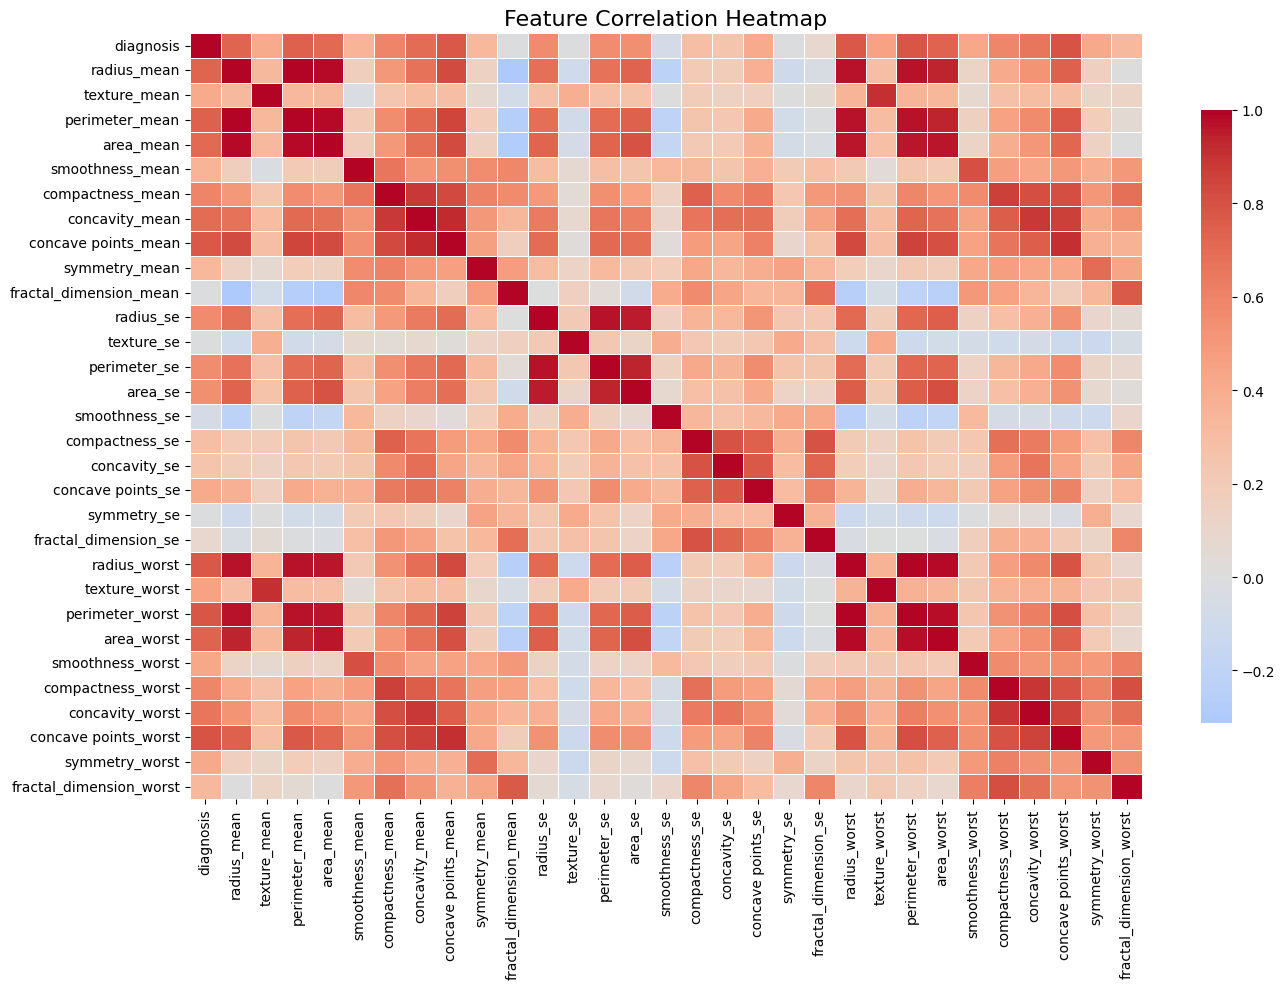

In [2]:
plt.figure(figsize=(14,10))

corr = df.drop(columns=['diagnosis_label']).corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Feature Correlation Heatmap", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The heatmap shows strong positive correlations between features such as radius, perimeter, and area, indicating redundancy among size-related attributes. Several features like concave points and concavity exhibit strong correlation with diagnosis, justifying their importance as inputs to the neural network.

## Feature Distribution - Violin Plots

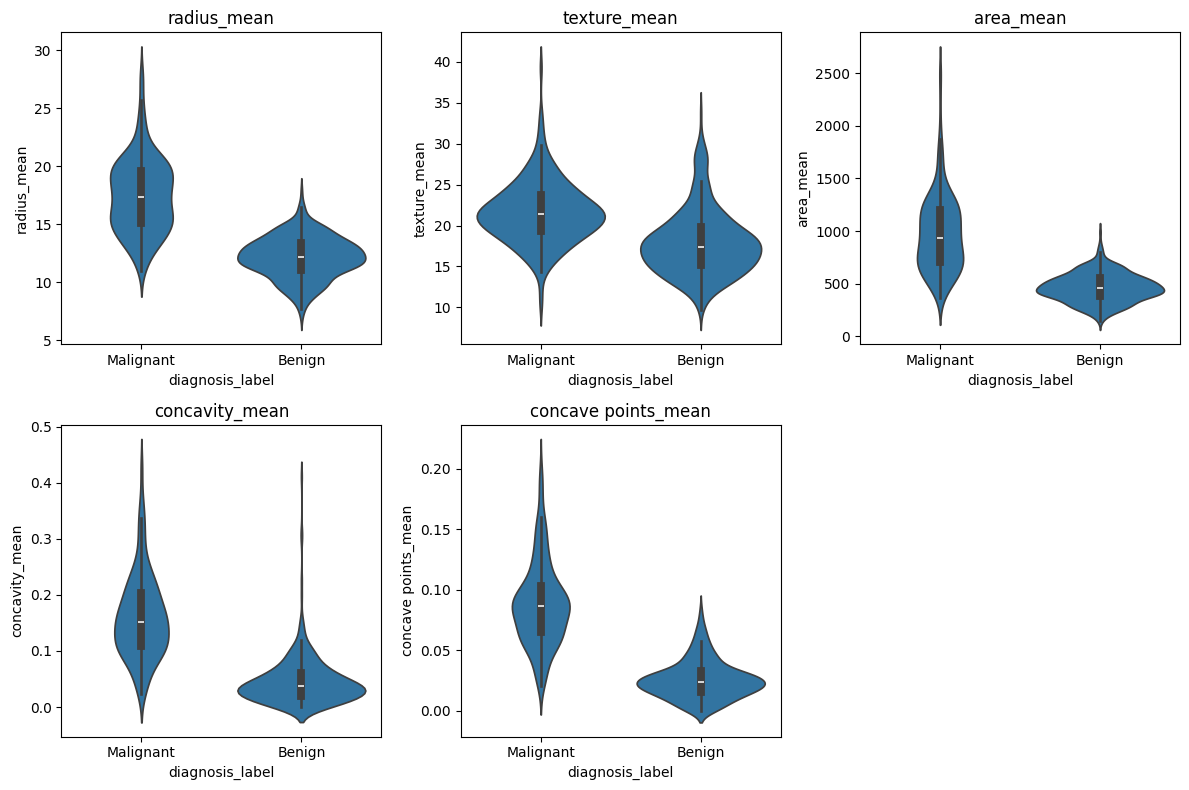

In [3]:
features = [
    'radius_mean',
    'texture_mean',
    'area_mean',
    'concavity_mean',
    'concave points_mean'
]

plt.figure(figsize=(12,8))

for i, feature in enumerate(features):
    plt.subplot(2,3,i+1)
    sns.violinplot(x='diagnosis_label', y=feature, data=df)
    plt.title(feature)

plt.tight_layout()
plt.show()

Several features such as concave points_mean and area_mean show clear separation between malignant and benign classes, indicating strong discriminative power. Features with overlapping distributions are less informative for classification

## Target Balance Pie Chart

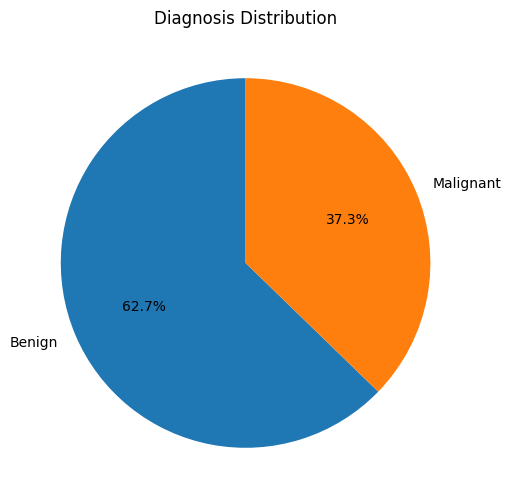

In [4]:
counts = df['diagnosis_label'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Diagnosis Distribution")
plt.show()

The dataset shows a moderate class imbalance, with benign cases slightly more frequent than malignant ones. However, the distribution is not severely skewed, making it suitable for training without major bias.

## Feature Correlation with Diagnosis

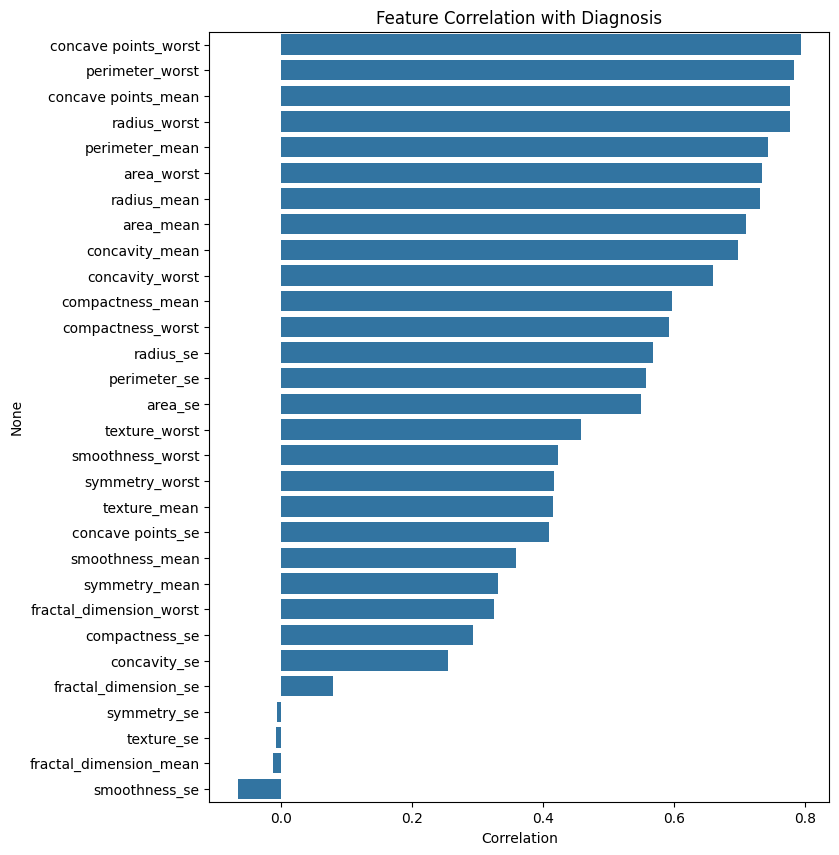

In [5]:
corr_target = corr['diagnosis'].drop('diagnosis').sort_values(ascending=False)

plt.figure(figsize=(8,10))
sns.barplot(x=corr_target.values, y=corr_target.index)

plt.title("Feature Correlation with Diagnosis")
plt.xlabel("Correlation")
plt.show()

The bar plot highlights that features related to tumor size, such as concave points and perimeter, have the highest correlation with diagnosis. This indicates their strong predictive importance for classification.

## Neural Network Architecture

The neural network follows a modular architecture where each layer is implemented as a separate class. The model consists of an input layer with 30 features, followed by a hidden layer of 16 neurons using ReLU activation, and a final output layer with a single neuron using Sigmoid activation for binary classification. This design enables clear separation of responsibilities, making the network scalable and easier to debug.

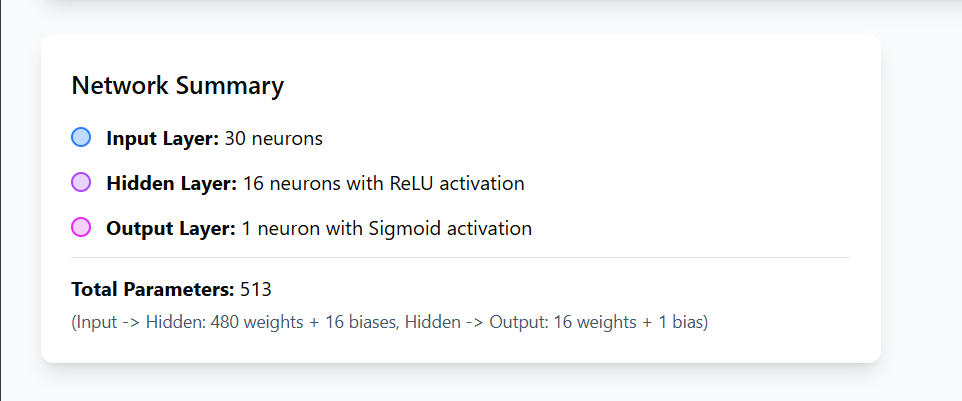

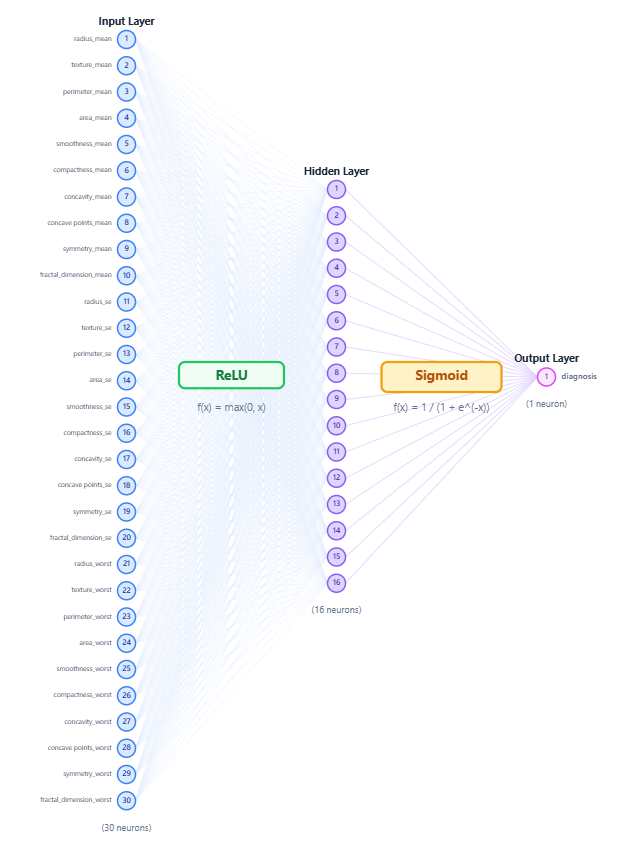

## Hyperparameter Experimentation

In [6]:
from class_based_init import DenseLayer, ReLU, Sigmoid, NeuralNetwork, epsilon
from load import Xtrain, Ytrain, Xtest, Ytest

def train_model(alpha, epochs=2000):
    N = Xtrain.shape[0]

    model = NeuralNetwork([
        DenseLayer(30,16),
        ReLU(),
        DenseLayer(16,1),
        Sigmoid()
    ])

    losses = []

    for i in range(epochs):
        predictions = model.forward(Xtrain)
        loss = -1/N * (
            Ytrain*np.log(predictions) +
            (1-Ytrain)*np.log(1-predictions)
        ).sum()

        losses.append(loss)
        
        grad = (predictions - Ytrain) / (predictions*(1-predictions) + epsilon)
        model.backward(grad)
        
        model.update(alpha)

    return losses, model

In [7]:
learning_rates = [0.1, 0.01, 0.005, 0.0001]

results = {}

for lr in learning_rates:
    print(f"Training with alpha = {lr}")
    losses, model = train_model(alpha=lr, epochs=2000)
    results[lr] = losses

Training with alpha = 0.1
Training with alpha = 0.01
Training with alpha = 0.005
Training with alpha = 0.0001


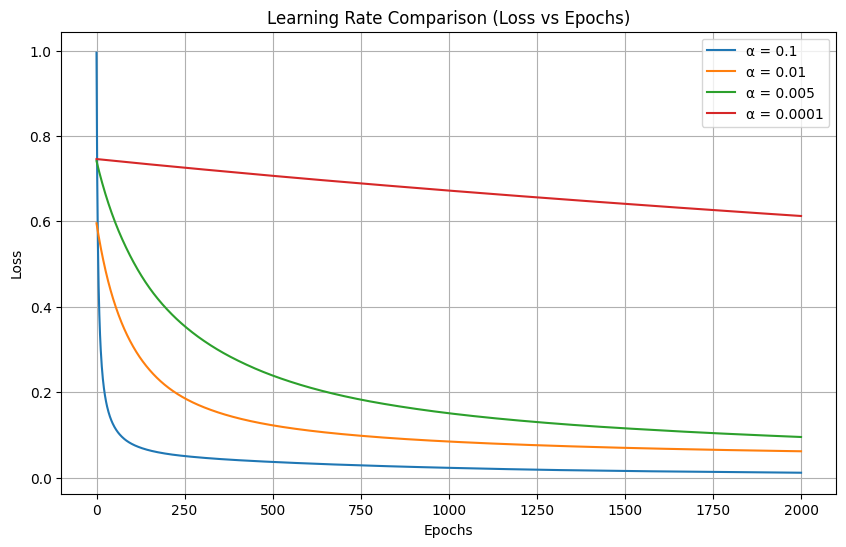

In [8]:
plt.figure(figsize=(10,6))

for lr, losses in results.items():
    plt.plot(losses, label=f"α = {lr}")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison (Loss vs Epochs)")
plt.legend()
plt.grid()

plt.show()

Different learning rates significantly impact training behavior. A high learning rate leads to unstable convergence, while a very small learning rate (0.0001) results in slow learning. A moderate value (0.001) provides a balance between speed and stability, demonstrating optimal convergence behavior.

## Predictions

In [9]:
losses, model = train_model(alpha=0.01, epochs=2000)
test_probs = model.forward(Xtest)

In [10]:
predictions = (test_probs >= 0.5).astype(int)
print("First 10 probabilities:\n", test_probs[:10])
print("First 10 predictions:\n", predictions[:10])
print("Actual labels:\n", Ytest[:10])

First 10 probabilities:
 [[9.98083972e-01]
 [9.92557118e-01]
 [1.27527178e-03]
 [9.98840981e-01]
 [9.99893377e-01]
 [6.13085061e-03]
 [6.89712436e-03]
 [1.01197042e-03]
 [9.99974516e-01]
 [8.03714191e-04]]
First 10 predictions:
 [[1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]]
Actual labels:
 [[1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]]


## Performance Metrics

In [11]:
TP = np.sum((predictions == 1) & (Ytest == 1))
TN = np.sum((predictions == 0) & (Ytest == 0))
FP = np.sum((predictions == 1) & (Ytest == 0))
FN = np.sum((predictions == 0) & (Ytest == 1))

In [12]:
accuracy = np.mean(predictions == Ytest)
print(f"Accuracy: {accuracy * 100:.2f}%")
recall = TP / (TP + FN + 1e-10)
print(f"Recall: {recall:.4f}")
fnr = FN / (TP + FN + 1e-10)
print(f"False Negative Rate: {fnr:.4f}")

Accuracy: 95.61%
Recall: 0.9149
False Negative Rate: 0.0851


## Confusion Matrix

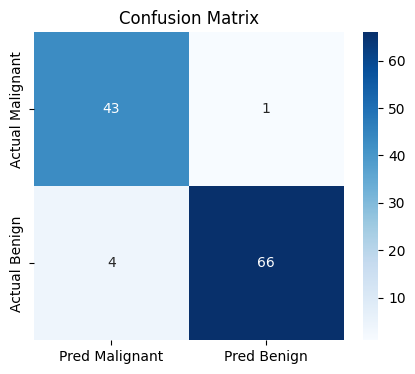

In [13]:
cm = np.array([[TP, FP],
               [FN, TN]])

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred Malignant", "Pred Benign"],
            yticklabels=["Actual Malignant", "Actual Benign"])

plt.title("Confusion Matrix")
plt.show()